# YOLO Object Detection in Google Colab

This notebook uses a pretrained YOLO model from the GitHub project
`yantaolab/Autonomous-Construction-and-Robotics`, specifically the
`Project 03 Construction Tool Classification` folder, to detect and recognize
construction tools across a series of images.

The notebook is designed for Google Colab and will:
- install the required Python package;
- download `best.pt` from the GitHub project;
- download test images from the project's `test/images` folder;
- run YOLO object detection;
- save the annotated image locally in the Colab runtime;
- display the annotated image directly in Colab.


## 1. Install dependencies

Google Colab normally provides PyTorch already, so there is no need to force-install a specific CUDA build. Installing `ultralytics` is sufficient for this notebook.

In [1]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.1 MB/s eta 0:00:00


## 2. Import libraries

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
from urllib.parse import urlparse

from IPython.display import Image, display
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


## 3. Configuration

The URLs below point to the `Project 03 Construction Tool Classification`
folder in the GitHub repository. The pretrained `best.pt` model is located in
`runs/detect/train/weights`, and test images are located in `test/images`.
Students can select an image from the `test/images` folder for testing.

Please note that images containing multiple tools should be chosen, as they are
more helpful for addressing Task 2. The detection results will be saved in the
`/content` directory, meaning that the generated images are stored locally
within the Colab runtime.


In [3]:
# GitHub project configuration
# Project 03 is stored inside the main Autonomous-Construction-and-Robotics repository.
PROJECT_URL = "https://github.com/yantaolab/Autonomous-Construction-and-Robotics/tree/main/Projects/Project%2003%20Construction%20Tool%20Classification"

# Raw GitHub URL for the trained YOLO weights.
# GitHub's normal /tree/ URL is a web page, so files are downloaded through
# raw.githubusercontent.com instead.
WEIGHTS_URL = (
    "https://raw.githubusercontent.com/"
    "yantaolab/Autonomous-Construction-and-Robotics/main/"
    "Projects/Project%2003%20Construction%20Tool%20Classification/runs/detect/train/weights/best.pt"
)

# ============================================================
# Only change IMAGE_URL when you want to detect another image.
# The input and output filenames are generated automatically.
# ============================================================
IMAGE_URL = (
    "https://raw.githubusercontent.com/"
    "yantaolab/Autonomous-Construction-and-Robotics/main/"
    "Projects/Project%2003%20Construction%20Tool%20Classification/test/images/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d.jpg"
)

# Local paths in the Google Colab runtime
WORK_DIR = Path("/content/construction_tool_classification")
WEIGHTS_PATH = WORK_DIR / "best.pt"
OUTPUT_DIR = WORK_DIR / "detection_results"

# Automatically derive the image filename from IMAGE_URL
image_filename = Path(urlparse(IMAGE_URL).path).name
if not image_filename:
    raise ValueError("Could not determine an image filename from IMAGE_URL.")

IMAGE_PATH = WORK_DIR / image_filename

# Automatically derive the annotated output filename
image_stem = Path(image_filename).stem
image_suffix = Path(image_filename).suffix or ".jpg"
OUTPUT_PATH = OUTPUT_DIR / f"{image_stem}_annotated{image_suffix}"

# YOLO confidence threshold
# In this assignment, students are required to modify the confidence threshold
# to 0.25, 0.50, and 0.75, and examine the corresponding detection results.
# The adjustment of the confidence threshold values should be made here.
CONF_THRESHOLD = 0.25

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input image:  {IMAGE_PATH}")
print(f"Output image: {OUTPUT_PATH}")


Input image:  /content/construction_tool_classification/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d.jpg
Output image: /content/construction_tool_classification/detection_results/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d_annotated.jpg


## 4. Download the pretrained model and test image

The files are downloaded only when they are not already present. This makes it safe to rerun the cell without downloading them again.

In [4]:
if not WEIGHTS_PATH.exists():
    print("Downloading pretrained YOLO weights from the new GitHub project...")
    urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)
else:
    print(f"Weights already exist: {WEIGHTS_PATH}")

# Download the selected test image from the project's test/images folder.
# If the file already exists, it is reused.
if not IMAGE_PATH.exists():
    print(f"Downloading test image from: {IMAGE_URL}")
    urlretrieve(IMAGE_URL, IMAGE_PATH)
else:
    print(f"Image already exists: {IMAGE_PATH}")

print(f"Weights: {WEIGHTS_PATH}")
print(f"Image:  {IMAGE_PATH}")
print(f"Output: {OUTPUT_PATH}")


Weights: /content/construction_tool_classification/best.pt
Image:  /content/construction_tool_classification/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d.jpg
Output: /content/construction_tool_classification/detection_results/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d_annotated.jpg


## 5. Load the pretrained YOLO model

`YOLO(WEIGHTS_PATH)` loads the `best.pt` model trained for the
Construction Tool Classification project in the GitHub repository.


In [5]:
if not WEIGHTS_PATH.exists():
    raise FileNotFoundError(f"Weights file not found: {WEIGHTS_PATH}")

model = YOLO(str(WEIGHTS_PATH))

print("Model loaded successfully.")
print(f"Model path: {WEIGHTS_PATH}")
print(f"Class names: {model.names}")

Model loaded successfully.
Model path: /content/construction_tool_classification/best.pt
Class names: {0: 'Drill', 1: 'Hammer', 2: 'Pliers', 3: 'Screwdriver', 4: 'Wrench'}


## 6. Run object detection

The model performs inference on the image specified by `IMAGE_URL`. The annotated result is generated with `results[0].plot()`.

The input and output filenames are derived automatically from `IMAGE_URL`, so you only need to change `IMAGE_URL` when using a different image.


In [6]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"Input image not found: {IMAGE_PATH}")

results = model.predict(
    source=str(IMAGE_PATH),
    conf=CONF_THRESHOLD,
    save=False,
    verbose=False,
)

annotated_image = results[0].plot()

print(f"Detection completed. Confidence threshold: {CONF_THRESHOLD}")
print(f"Number of detected objects: {len(results[0].boxes)}")

Detection completed. Confidence threshold: 0.25
Number of detected objects: 3


## 7. Save the annotated image locally

The annotated image is saved automatically using the input image's filename:

`<original_filename>_annotated.<extension>`

For example, if `IMAGE_URL` points to `abc.jpg`, the output will be `abc_annotated.jpg`.

The file remains available under `/content/construction_tool_detection/detection_results/` for the current Colab session.


In [7]:
import cv2

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

success = cv2.imwrite(str(OUTPUT_PATH), annotated_image)

if not success:
    raise RuntimeError(f"Failed to save annotated image: {OUTPUT_PATH}")

print(f"Annotated image saved to: {OUTPUT_PATH}")

Annotated image saved to: /content/construction_tool_classification/detection_results/000012_jpg.rf.fd77bbfb2e4baa9c064c61451f3a200d_annotated.jpg


## 8. Display the result in Google Colab

The saved JPG is displayed directly in the notebook. This works in Google Colab without opening an OpenCV window.

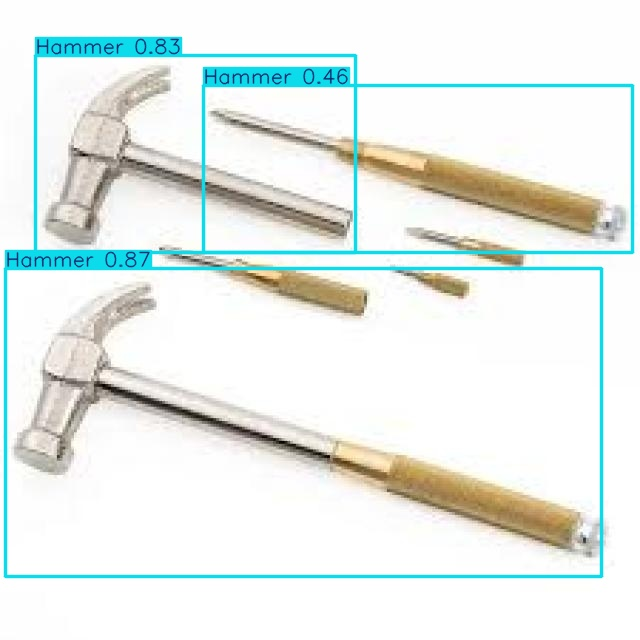

In [8]:
display(Image(filename=str(OUTPUT_PATH)))

## 9. Optional: print detected classes and confidence scores

This section provides a simple summary of the objects detected in the image.

In [9]:
result = results[0]

if len(result.boxes) == 0:
    print("No objects were detected.")
else:
    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]
        print(f"{class_name}: {confidence:.3f}")

Hammer: 0.868
Hammer: 0.830
Hammer: 0.464


## 10. Output location

In Google Colab, you can find the annotated result in the left-side **Files**
panel under `/content/construction_tool_classification/detection_results/`.

The original model and test images are downloaded from the
`Project 03 Construction Tool Classification` folder in the GitHub repository.
